In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mosek.fusion as M

def SigmoidalBasis(A, b, x):
    n = len(A)
    coef = np.array(len(x) * [b]).T
    u = A @ x.T + coef
    return np.fmax(u, 0)

def LogCost(X, Y):
    cost = np.empty((len(X), len(Y)))
    for i in range(len(X)):
        for j in range(len(Y)):
            cost[i, j] = np.log(1 - X[i] @ Y[j])
    return cost

In [2]:

def ReflectorOT_MOSEK_Fusion(X, Y, logcost, A, b, verbose=False):
    """
    MOSEK Fusion implementation for reflector optimal transport problem.

    Solves the dual problem:
    max sum_i phi(x_i)/n + sum_j psi(y_j)/m
    s.t. phi(x_i) + psi(y_j) <= cost[i,j] for all i,j

    Where phi and psi are parameterized using ReLU neural networks.

    Args:
        X: source points (n x d)
        Y: target points (m x d)
        logcost: cost matrix (n x m)
        A: neural network weights (k x d)
        b: neural network biases (k,)
        verbose: print solver output

    Returns:
        phi_weights, psi_weights, phi_basis, psi_basis, obj_val
    """
    n, m = len(X), len(Y)

    # Compute ReLU basis functions: max(A @ x + b, 0)
    def compute_basis(points):
        basis = np.zeros((len(points), len(b)))
        for i, point in enumerate(points):
            activations = A @ point + b
            basis[i] = np.maximum(activations, 0)
        return basis

    phi_basis = compute_basis(X)  # (n x k)
    psi_basis = compute_basis(Y)  # (m x k)
    k = phi_basis.shape[1]

    # Create MOSEK Fusion model
    with M.Model("ReflectorOT") as model:
        
        # Set verbosity
        if not verbose:
            model.setLogHandler(lambda x: None)
        
        # Variables: phi_weights (k), psi_weights (k)
        phi_weights = model.variable("phi", k, M.Domain.unbounded())
        psi_weights = model.variable("psi", k, M.Domain.unbounded())
        
        # Constraints: phi(x_i) + psi(y_j) <= cost[i,j] for all i,j
        for i in range(n):
            for j in range(m):
                # phi(x_i) = phi_basis[i, :] @ phi_weights
                # psi(y_j) = psi_basis[j, :] @ psi_weights
                phi_at_xi = M.Expr.dot(phi_basis[i, :], phi_weights)
                psi_at_yj = M.Expr.dot(psi_basis[j, :], psi_weights)
                
                # Constraint: phi(x_i) + psi(y_j) <= cost[i,j]
                model.constraint(f"dual_constraint_{i}_{j}",
                               M.Expr.add(phi_at_xi, psi_at_yj),
                               M.Domain.lessThan(logcost[i, j]))
        
        # Objective: maximize (1/n) * sum_i phi(x_i) + (1/m) * sum_j psi(y_j)
        # = max sum_k [(1/n * sum_i phi_basis[i,k]) * phi_k + (1/m * sum_j psi_basis[j,k]) * psi_k]
        
        # Compute objective coefficients
        phi_obj_coeffs = np.mean(phi_basis, axis=0)  # (1/n) * sum_i phi_basis[i, :]
        psi_obj_coeffs = np.mean(psi_basis, axis=0)  # (1/m) * sum_j psi_basis[j, :]
        
        # Build objective expression
        phi_obj = M.Expr.dot(phi_obj_coeffs, phi_weights)
        psi_obj = M.Expr.dot(psi_obj_coeffs, psi_weights)
        total_obj = M.Expr.add(phi_obj, psi_obj)
        
        # Set objective (maximize)
        model.objective(M.ObjectiveSense.Maximize, total_obj)
        
        # Solve the problem
        model.solve()
        
        # Check solution status
        if model.getPrimalSolutionStatus() == M.SolutionStatus.Optimal:
            # Get solution values
            phi_sol = phi_weights.level()
            psi_sol = psi_weights.level()
            obj_val = model.primalObjValue()
            
            return np.array(phi_sol), np.array(psi_sol), phi_basis, psi_basis, obj_val
        
        else:
            print(f"MOSEK Fusion optimization failed with status: {model.getPrimalSolutionStatus()}")
            return None, None, phi_basis, psi_basis, None


In [3]:
def RandSphereCap(x, v1, v2, r, N):
    r = np.random.uniform(0, r, size=N)
    theta = np.random.uniform(0, 2*np.pi, size=N)
    
    flat_points = np.array([np.sqrt(r[i])*(np.cos(theta[i])*v1+np.sin(theta[i])*v2) for i in range(N)])
    
    points = [h + np.sqrt(1-h@h)*x for h in flat_points]
    
    return np.array(points)

In [4]:
e = np.eye(3)
N = 100
    
X = RandSphereCap(e[0], e[1], e[2], 0.3, N)
Y = RandSphereCap(e[1], e[0], e[2], 0.2, N)
    
C = LogCost(X, Y)
print(f"Cost Matrix shape: {C.shape}")
print(f"Cost Matrix: {C}")

Cost Matrix shape: (100, 100)
Cost Matrix: [[-2.20492475e-01 -7.21639895e-01 -1.03089314e+00 ... -4.24413027e-01
  -3.25764346e-01  6.51249615e-02]
 [ 1.28265648e-01 -7.48720943e-02 -3.95227081e-01 ... -1.78166155e-02
   1.15624035e-01  3.95110366e-01]
 [-9.39589344e-03 -1.65062873e-01 -5.88314331e-01 ... -1.75615261e-01
  -2.25033925e-03  3.21840930e-01]
 ...
 [-3.52719559e-01 -6.48137422e-01 -1.22183793e+00 ... -5.84406814e-01
  -3.89514759e-01  5.46520842e-02]
 [-4.90241946e-01 -6.56254376e-01 -1.39453270e+00 ... -7.43176802e-01
  -4.82557346e-01  7.13053742e-04]
 [-2.02026406e-01 -5.13007046e-02 -6.24885752e-01 ... -3.56442944e-01
  -8.08526818e-02  2.53865020e-01]]


In [5]:
 # Neural network parameters
k = 50  # number of neurons
A = 10 * (np.random.rand(k, 3) - 0.5 * np.ones((k, 3)))
b = 10 * (np.random.rand(k) - 0.5 * np.ones(k))

In [6]:
# Solve using MOSEK Fusion
try:
    phi, psi, basis1, basis2, obj_val = ReflectorOT_MOSEK_Fusion(X, Y, C, A, b, verbose=True)
    
    if phi is not None:
        print(f"Optimization successful!")
        print(f"Objective value: {obj_val}")
        print(f"Phi weights shape: {phi.shape}")
        print(f"Psi weights shape: {psi.shape}")
    else:
        print("Optimization failed")
        
except Exception as e:
    print(f"Error during optimization: {e}")

Optimization successful!
Objective value: -0.24076024813678032
Phi weights shape: (50,)
Psi weights shape: (50,)


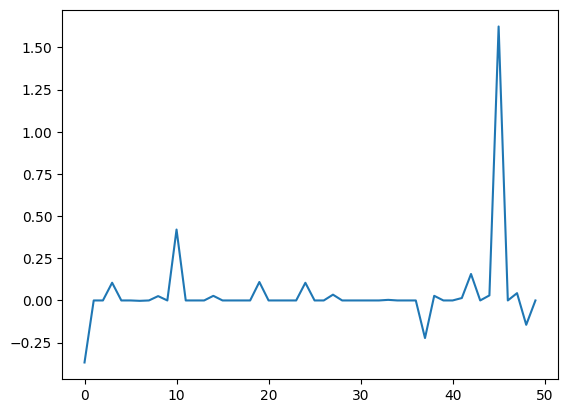

In [8]:
phi_vals = basis1 @ phi
rho = np.exp(phi_vals)
R = np.empty(X.shape)
for k in range(len(rho)):
    R[k] = rho[k]*X[k]
plt.plot(phi)